<a href="https://colab.research.google.com/github/Jayalekshmi872/AI-ML_ICTK/blob/main/assignment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [416]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [417]:
df= pd.read_csv('/content/tweets.csv')
df

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone
1,2,0,Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/
2,3,0,We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu
3,4,0,I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/
4,5,1,What amazing service! Apple won't even talk to me about a question I have unless I pay them $19.95 for their stupid support!
...,...,...,...
7915,7916,0,Live out loud #lol #liveoutloud #selfie #smile #sony #music #headphones https://instagram.com/p/5spiNsJ_c9/
7916,7917,0,"We would like to wish you an amazing day! Make every minute count #tls #today #iphone #accessories #news #life February 23, 2017 at 0…"
7917,7918,0,Helping my lovely 90 year old neighbor with her iPad this morning has just made me realise that 'I' don't actually need an I pad!
7918,7919,0,"Finally got my #smart #pocket #wifi stay connected anytime,anywhere! #ipad and #samsung #s3 #gadget # http://instagr.am/p/U-53G_vJU8/"


In [418]:
df.shape

(7920, 3)

In [419]:
df.columns

Index(['id', 'label', 'tweet'], dtype='object')

In [420]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7920 non-null   int64 
 1   label   7920 non-null   int64 
 2   tweet   7920 non-null   object
dtypes: int64(2), object(1)
memory usage: 185.8+ KB


In [421]:
df.describe()

,id,label
count,7920.000000,7920.000000
mean,3960.500000,0.255808
std,2286.451399,0.436342
min,1.000000,0.000000
25%,1980.750000,0.000000
50%,3960.500000,0.000000
75%,5940.250000,1.000000
max,7920.000000,1.000000


In [422]:
df.isna().sum()

,0
id,0
label,0
tweet,0


In [423]:
df.duplicated().sum()

np.int64(0)

In [424]:
df['label'].value_counts()

,count
label,
0,5894
1,2026


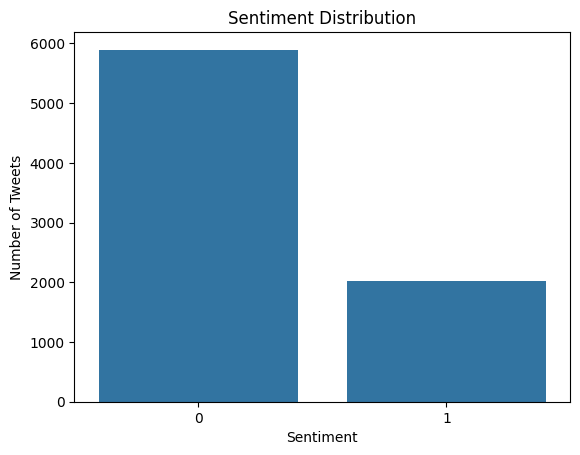

In [425]:
sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()


In [426]:
df.groupby('label')['tweet'].count()

,tweet
label,
0,5894
1,2026


In [427]:
print("Label 0 examples:")
print(df[df['label'] == 0]['tweet'].head(5))

Label 0 examples:
0       #fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone
1    Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/
2            We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu
3                       I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/
6                                   Happy for us .. #instapic #instadaily #us #sony #xperia #xperiaZ https://instagram.com/p/z9qGfWlvj7/
Name: tweet, dtype: object


In [428]:
print("Label 1 examples:")
print(df[df['label'] == 1]['tweet'].head(5))

Label 1 examples:
4     What amazing service! Apple won't even talk to me about a question I have unless I pay them $19.95 for their stupid support!
5                                                                iPhone software update fucked up my phone big time Stupid iPhones
10    hey #apple when you make a new ipod dont make it a new color or .2inches thinner make it not crash every five fuckin minite.
11      Ha! Not heavy machinery but it does what I need it to. @Apple really dropped the ball with that design. #drinkyourhaterade
12            Contemplating giving in to the iPhone bandwagon simply because #Cellcom has no new Androids #depressing #IDontWantTo
Name: tweet, dtype: object


In [429]:
df = df[['tweet', 'label']]

In [430]:
df

,tweet,label
0,#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone,0
1,Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/,0
2,We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu,0
3,I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/,0
4,What amazing service! Apple won't even talk to me about a question I have unless I pay them $19.95 for their stupid support!,1
...,...,...
7915,Live out loud #lol #liveoutloud #selfie #smile #sony #music #headphones https://instagram.com/p/5spiNsJ_c9/,0
7916,"We would like to wish you an amazing day! Make every minute count #tls #today #iphone #accessories #news #life February 23, 2017 at 0…",0
7917,Helping my lovely 90 year old neighbor with her iPad this morning has just made me realise that 'I' don't actually need an I pad!,0
7918,"Finally got my #smart #pocket #wifi stay connected anytime,anywhere! #ipad and #samsung #s3 #gadget # http://instagr.am/p/U-53G_vJU8/",0


In [431]:
#clean the text

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r'#', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove Unicode ellipsis
    text = text.replace('…', '')

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [432]:
df['clean_tweet']=df['tweet'].apply(clean_text)

In [433]:
df[['tweet', 'clean_tweet']].head(10)

,tweet,clean_tweet
0,#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone,fingerprint pregnancy test android apps beautiful cute health igers iphoneonly iphonesia iphone
1,Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/,finally a transparant silicon case thanks to my uncle yay sony xperia s sonyexperias
2,We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu,we love this would you go talk makememories unplug relax iphone smartphone wifi connect
3,I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/,im wired i know im george i was made that way iphone cute daventry home
4,What amazing service! Apple won't even talk to me about a question I have unless I pay them $19.95 for their stupid support!,what amazing service apple wont even talk to me about a question i have unless i pay them for their stupid support
5,iPhone software update fucked up my phone big time Stupid iPhones,iphone software update fucked up my phone big time stupid iphones
6,Happy for us .. #instapic #instadaily #us #sony #xperia #xperiaZ https://instagram.com/p/z9qGfWlvj7/,happy for us instapic instadaily us sony xperia xperiaz
7,New Type C charger cable #UK http://www.ebay.co.uk/itm/-/112598674021 … #bay #Amazon #etsy New Year #Rob Cross #Toby Young #EVEMUN #McMafia #Taylor #SPECTRE 2018 #NewYear #Starting 2018 #recipes #technology #SamsungGalaxyS9 #iPhoneX pic.twitter.com/PjIwq59WtC,new type c charger cable uk bay amazon etsy new year rob cross toby young evemun mcmafia taylor spectre newyear starting recipes technology samsunggalaxys iphonex pictwittercompjiwqwtc
8,Bout to go shopping again listening to music #iphone #justme #music #likeforlike #followforfollow… http://instagr.am/p/Vj6bg5tLql/,bout to go shopping again listening to music iphone justme music likeforlike followforfollow
9,Photo: #fun #selfie #pool #water #sony #camera #picoftheday #sun #instagood #boy #cute #outdoor... http://tmblr.co/ZAjC0n1ms_Gp8,photo fun selfie pool water sony camera picoftheday sun instagood boy cute outdoor


In [434]:
pd.set_option('display.max_colwidth', None)

df[['tweet', 'clean_tweet']].head(10)

,tweet,clean_tweet
0,#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone,fingerprint pregnancy test android apps beautiful cute health igers iphoneonly iphonesia iphone
1,Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/,finally a transparant silicon case thanks to my uncle yay sony xperia s sonyexperias
2,We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu,we love this would you go talk makememories unplug relax iphone smartphone wifi connect
3,I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/,im wired i know im george i was made that way iphone cute daventry home
4,What amazing service! Apple won't even talk to me about a question I have unless I pay them $19.95 for their stupid support!,what amazing service apple wont even talk to me about a question i have unless i pay them for their stupid support
5,iPhone software update fucked up my phone big time Stupid iPhones,iphone software update fucked up my phone big time stupid iphones
6,Happy for us .. #instapic #instadaily #us #sony #xperia #xperiaZ https://instagram.com/p/z9qGfWlvj7/,happy for us instapic instadaily us sony xperia xperiaz
7,New Type C charger cable #UK http://www.ebay.co.uk/itm/-/112598674021 … #bay #Amazon #etsy New Year #Rob Cross #Toby Young #EVEMUN #McMafia #Taylor #SPECTRE 2018 #NewYear #Starting 2018 #recipes #technology #SamsungGalaxyS9 #iPhoneX pic.twitter.com/PjIwq59WtC,new type c charger cable uk bay amazon etsy new year rob cross toby young evemun mcmafia taylor spectre newyear starting recipes technology samsunggalaxys iphonex pictwittercompjiwqwtc
8,Bout to go shopping again listening to music #iphone #justme #music #likeforlike #followforfollow… http://instagr.am/p/Vj6bg5tLql/,bout to go shopping again listening to music iphone justme music likeforlike followforfollow
9,Photo: #fun #selfie #pool #water #sony #camera #picoftheday #sun #instagood #boy #cute #outdoor... http://tmblr.co/ZAjC0n1ms_Gp8,photo fun selfie pool water sony camera picoftheday sun instagood boy cute outdoor


In [435]:
for i in range(10):
    print("Original:")
    print(df.loc[i, 'tweet'])

    print("\nCleaned:")
    print(df.loc[i, 'clean_tweet'])

    print("=" * 100)

Original:
#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone

Cleaned:
fingerprint pregnancy test android apps beautiful cute health igers iphoneonly iphonesia iphone
Original:
Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/

Cleaned:
finally a transparant silicon case thanks to my uncle yay sony xperia s sonyexperias
Original:
We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu

Cleaned:
we love this would you go talk makememories unplug relax iphone smartphone wifi connect
Original:
I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/

Cleaned:
im wired i know im george i was made that way iphone cute daventry home
Original:
What amazing service! Apple won't even talk to me about a question I ha

In [436]:
df

,tweet,label,clean_tweet
0,#fingerprint #Pregnancy Test https://goo.gl/h1MfQV #android #apps #beautiful #cute #health #igers #iphoneonly #iphonesia #iphone,0,fingerprint pregnancy test android apps beautiful cute health igers iphoneonly iphonesia iphone
1,Finally a transparant silicon case ^^ Thanks to my uncle :) #yay #Sony #Xperia #S #sonyexperias… http://instagram.com/p/YGEt5JC6JM/,0,finally a transparant silicon case thanks to my uncle yay sony xperia s sonyexperias
2,We love this! Would you go? #talk #makememories #unplug #relax #iphone #smartphone #wifi #connect... http://fb.me/6N3LsUpCu,0,we love this would you go talk makememories unplug relax iphone smartphone wifi connect
3,I'm wired I know I'm George I was made that way ;) #iphone #cute #daventry #home http://instagr.am/p/Li_5_ujS4k/,0,im wired i know im george i was made that way iphone cute daventry home
4,What amazing service! Apple won't even talk to me about a question I have unless I pay them $19.95 for their stupid support!,1,what amazing service apple wont even talk to me about a question i have unless i pay them for their stupid support
...,...,...,...
7915,Live out loud #lol #liveoutloud #selfie #smile #sony #music #headphones https://instagram.com/p/5spiNsJ_c9/,0,live out loud lol liveoutloud selfie smile sony music headphones
7916,"We would like to wish you an amazing day! Make every minute count #tls #today #iphone #accessories #news #life February 23, 2017 at 0…",0,we would like to wish you an amazing day make every minute count tls today iphone accessories news life february at
7917,Helping my lovely 90 year old neighbor with her iPad this morning has just made me realise that 'I' don't actually need an I pad!,0,helping my lovely year old neighbor with her ipad this morning has just made me realise that i dont actually need an i pad
7918,"Finally got my #smart #pocket #wifi stay connected anytime,anywhere! #ipad and #samsung #s3 #gadget # http://instagr.am/p/U-53G_vJU8/",0,finally got my smart pocket wifi stay connected anytimeanywhere ipad and samsung s gadget


In [437]:
(df['clean_tweet'] == '').sum()

np.int64(0)

In [438]:
df.drop(columns='tweet',inplace=True)

In [439]:
df

,label,clean_tweet
0,0,fingerprint pregnancy test android apps beautiful cute health igers iphoneonly iphonesia iphone
1,0,finally a transparant silicon case thanks to my uncle yay sony xperia s sonyexperias
2,0,we love this would you go talk makememories unplug relax iphone smartphone wifi connect
3,0,im wired i know im george i was made that way iphone cute daventry home
4,1,what amazing service apple wont even talk to me about a question i have unless i pay them for their stupid support
...,...,...
7915,0,live out loud lol liveoutloud selfie smile sony music headphones
7916,0,we would like to wish you an amazing day make every minute count tls today iphone accessories news life february at
7917,0,helping my lovely year old neighbor with her ipad this morning has just made me realise that i dont actually need an i pad
7918,0,finally got my smart pocket wifi stay connected anytimeanywhere ipad and samsung s gadget


In [440]:
#splitx and y
x= df['clean_tweet']
y=df['label']

In [441]:
x

,clean_tweet
0,fingerprint pregnancy test android apps beautiful cute health igers iphoneonly iphonesia iphone
1,finally a transparant silicon case thanks to my uncle yay sony xperia s sonyexperias
2,we love this would you go talk makememories unplug relax iphone smartphone wifi connect
3,im wired i know im george i was made that way iphone cute daventry home
4,what amazing service apple wont even talk to me about a question i have unless i pay them for their stupid support
...,...
7915,live out loud lol liveoutloud selfie smile sony music headphones
7916,we would like to wish you an amazing day make every minute count tls today iphone accessories news life february at
7917,helping my lovely year old neighbor with her ipad this morning has just made me realise that i dont actually need an i pad
7918,finally got my smart pocket wifi stay connected anytimeanywhere ipad and samsung s gadget


In [442]:
y

,label
0,0
1,0
2,0
3,0
4,1
...,...
7915,0
7916,0
7917,0
7918,0


###Train-Test split



In [443]:
from numpy.random.mtrand import rand
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [444]:
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)
print("Training data:", y_train.shape)
print("Testing data:", y_test.shape)

Training data: (6336,)
Testing data: (1584,)
Training data: (6336,)
Testing data: (1584,)


##Apply TF-IDF

In [445]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [446]:
X_train_tfidf = tfidf.fit_transform(x_train)

In [447]:
X_test_tfidf = tfidf.transform(x_test)

In [448]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (6336, 5000)
Testing TF-IDF shape: (1584, 5000)


##Train Logistic Regression Model

In [449]:
model = LogisticRegression(max_iter=1000)

In [450]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [451]:
y_pred = model.predict(X_test_tfidf)

In [452]:
print(y_pred[:20])

[1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1]


In [453]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.884469696969697


In [454]:
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 88.45%


In [455]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.96      0.92      1179
           1       0.84      0.68      0.75       405

    accuracy                           0.88      1584
   macro avg       0.87      0.82      0.84      1584
weighted avg       0.88      0.88      0.88      1584



In [456]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1126   53]
 [ 130  275]]


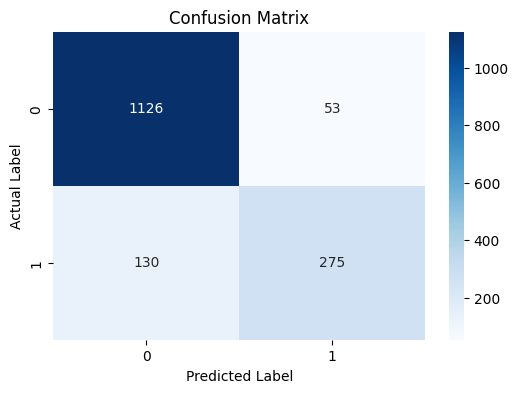

In [457]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [458]:
new_tweets = [
    "I absolutely love my new iPhone, the camera is amazing!",
    "This laptop is terrible and stopped working after one week.",
    "The customer service was excellent and very helpful.",
    "I hate this phone, it is slow and useless."
]

In [459]:
clean_new_tweets = [clean_text(tweet) for tweet in new_tweets]

In [460]:
new_tweets_tfidf = tfidf.transform(clean_new_tweets)

In [461]:
predictions = model.predict(new_tweets_tfidf)

In [462]:
for tweet, prediction in zip(new_tweets, predictions):

    if prediction == 1:
        sentiment = "Negative"
    else:
        sentiment = "Positive"

    print("Tweet:", tweet)
    print("Sentiment:", sentiment)
    print()

Tweet: I absolutely love my new iPhone, the camera is amazing!
Sentiment: Positive

Tweet: This laptop is terrible and stopped working after one week.
Sentiment: Negative

Tweet: The customer service was excellent and very helpful.
Sentiment: Positive

Tweet: I hate this phone, it is slow and useless.
Sentiment: Negative



In [463]:
#function for prediction
def predict_sentiment(tweet):

    # Clean the tweet
    cleaned_tweet = clean_text(tweet)

    # Convert to TF-IDF
    tweet_tfidf = tfidf.transform([cleaned_tweet])

    # Predict
    prediction = model.predict(tweet_tfidf)[0]

    if prediction == 0:
        return "Positive"
    else:
        return "Negative"

In [464]:
predict_sentiment("I love this new laptop!")

'Positive'

In [465]:
predict_sentiment("This phone is horrible and very slow.")

'Negative'

In [466]:
test_tweets = [
    "The phone has an amazing camera",
    "Worst laptop I have ever bought",
    "I am really happy with this product",
    "The battery life is terrible",
    "Excellent customer service",
    'bad service',
    'This laptop is terrible and stopped working after one week.'
]

for tweet in test_tweets:
    print(tweet, "---->", predict_sentiment(tweet))

The phone has an amazing camera ----> Positive
Worst laptop I have ever bought ----> Positive
I am really happy with this product ----> Positive
The battery life is terrible ----> Positive
Excellent customer service ----> Positive
bad service ----> Positive
This laptop is terrible and stopped working after one week. ----> Negative


In [467]:
final_accuracy = accuracy_score(y_test, y_pred)

print(f"Final Model Accuracy: {final_accuracy:.4f}")
print(f"Final Model Accuracy: {final_accuracy * 100:.2f}%")

Final Model Accuracy: 0.8845
Final Model Accuracy: 88.45%


In [468]:
print(y_test.value_counts())

label
0    1179
1     405
Name: count, dtype: int64


In [469]:
print(y_test.value_counts())
print(pd.Series(y_pred).value_counts())

label
0    1179
1     405
Name: count, dtype: int64
0    1256
1     328
Name: count, dtype: int64
